In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
from PIL import Image
import os

In [2]:
    # k_MAP = np.zeros_like(imageChannel, dtype = np.float64)
    # min_pixel = np.min(imageChannel)
    # max_pixel = np.max(imageChannel)
    # pixel_range = max_pixel - min_pixel

    # T_val = [min_pixel] + [min_pixel + (T * pixel_range) for T in Threshold] + [max_pixel]

    # for i in range(len(Threshold) + 1):
        
    #     mask = (imageChannel <= T_val[i+1]) & (imageChannel > T_val[i])
    #     slope = (K[i+1] - K[i]) / (T_val[i+1] - T_val[i])
    #     k_MAP[mask] = (slope * (imageChannel[mask] - T_val[i])) + K[i]
    # k_MAP[imageChannel > T_val[-1]] = K[-1]


    # if np.median(imageChannel) > 0:
    #     sigma = np.median(imageChannel) / 0.6745
    # else:
    #     sigma = 1e-6

    # T1 = sigma
    # T2 = np.percentile(imageChannel, 90) + 1e-6
    # k_MAP = K_MAX * (imageChannel / (imageChannel + T1)) * np.exp(-imageChannel / T2)


In [3]:
kernel = np.array([[-1, -1, -1],
                   [-1, 8, -1],
                   [-1, -1, -1]])

def createKValueMap(imageChannel, K_MAX = 7.0):
    if np.median(imageChannel) > 0:
        sigma = np.median(imageChannel) / 0.6745
    else:
        sigma = 1e-6

    T1 = sigma
    T2 = np.percentile(imageChannel, 90) + 1e-6
    k_MAP = K_MAX * (imageChannel / (imageChannel + T1)) * np.exp(-imageChannel / T2)
    return k_MAP

def var_k(image, K_MAX = 7):
    k_values = np.zeros_like(image, dtype = np.float64)

    if len(image.shape) > 2 and image.shape[2] != 0:
        for channel in range(image.shape[2]):
            k_values[:, :, channel] = createKValueMap(image[:, :, channel], K_MAX)
    else:
        k_values = createKValueMap(image, K_MAX)
    
    return k_values
            
def convolve_image(image, kernel):
    img_conv = np.zeros_like(image)
    if len(image.shape) > 2 and image.shape[2] != 0:
        for channel in range(image.shape[2]):
            img_conv[:, :, channel] = convolve(image[:, :, channel], kernel)
    else:
        img_conv = convolve(image, kernel)
    return img_conv

def highBoost_fixed(image, kernel, K = 1):
    image = image.astype(np.float64)
    img_conv = convolve_image(image, kernel)
    result = image.astype(np.float64) + K * img_conv
    result = np.clip(result, 0, 255).astype(np.uint8)
    return result

def highBoost_variable(image, kernel, K_MAX = 7):
    image = image.astype(np.float64)
    img_conv = convolve_image(image, kernel)
    k_values = var_k(np.abs(img_conv), K_MAX)
    result = image + (k_values * img_conv)
    result = np.clip(result, 0, 255).astype(np.uint8)
    return result

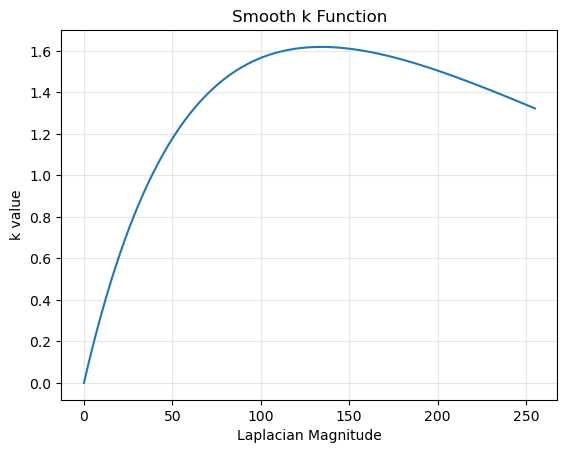

In [4]:
x = np.linspace(0, 255, 100)
Threshold = (0.3, 0.55)
K = (0.85, 1.00, 0.75)
k_piece = var_k(x)

plt.figure()
plt.plot(x, k_piece)
plt.xlabel("Laplacian Magnitude")
plt.ylabel("k value")
plt.title("Smooth k Function")
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
data_dir = 'data/'
image_files = os.listdir(data_dir)
images = []
for img_name in image_files:
    images.append(np.array(Image.open(data_dir + img_name)))
images[-1] = images[-1][:,:,:3]

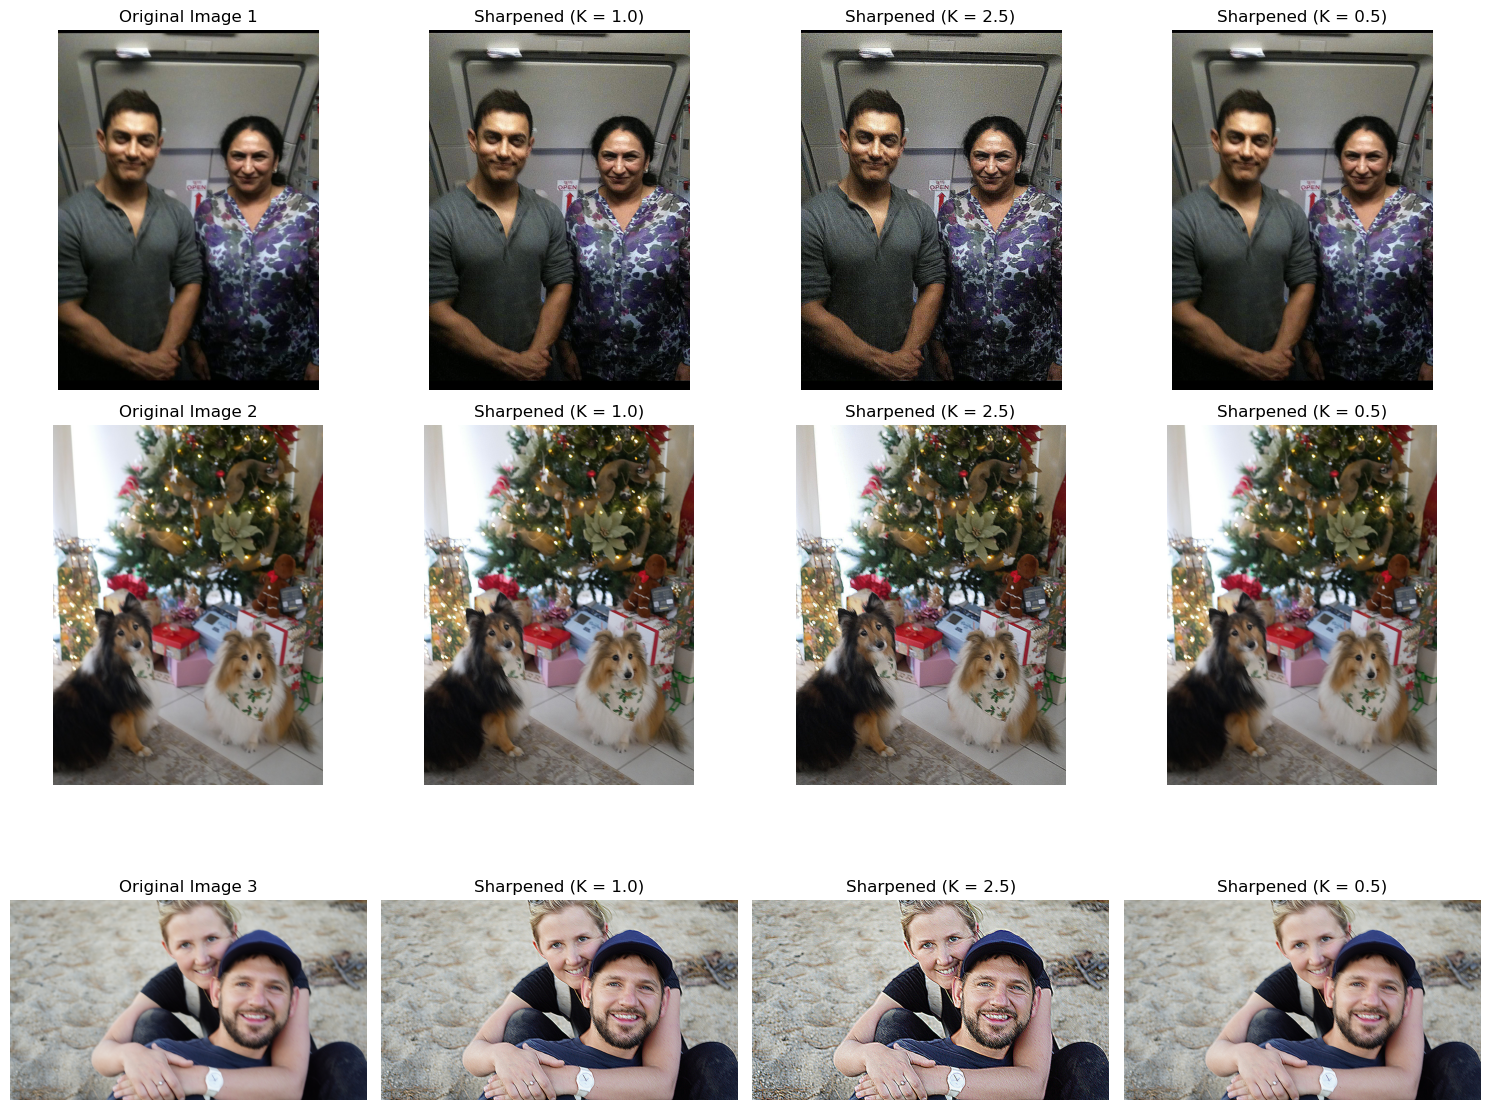

In [6]:
fig, axes = plt.subplots(nrows = 3, ncols = 4, figsize = (15, 12))
K = [1.0, 2.5, 0.5]

for i, img in enumerate(images):
    axes[i, 0].imshow(images[i], cmap='gray')
    axes[i, 0].set_title(f'Original Image {i + 1}')
    axes[i, 0].axis('off')

    for j, k in enumerate(K):
        axes[i, j+1].imshow(highBoost_fixed(images[i], kernel, K = k), cmap='gray')
        axes[i, j+1].set_title(f'Sharpened (K = {k})')
        axes[i, j+1].axis('off')

plt.tight_layout()
plt.show()

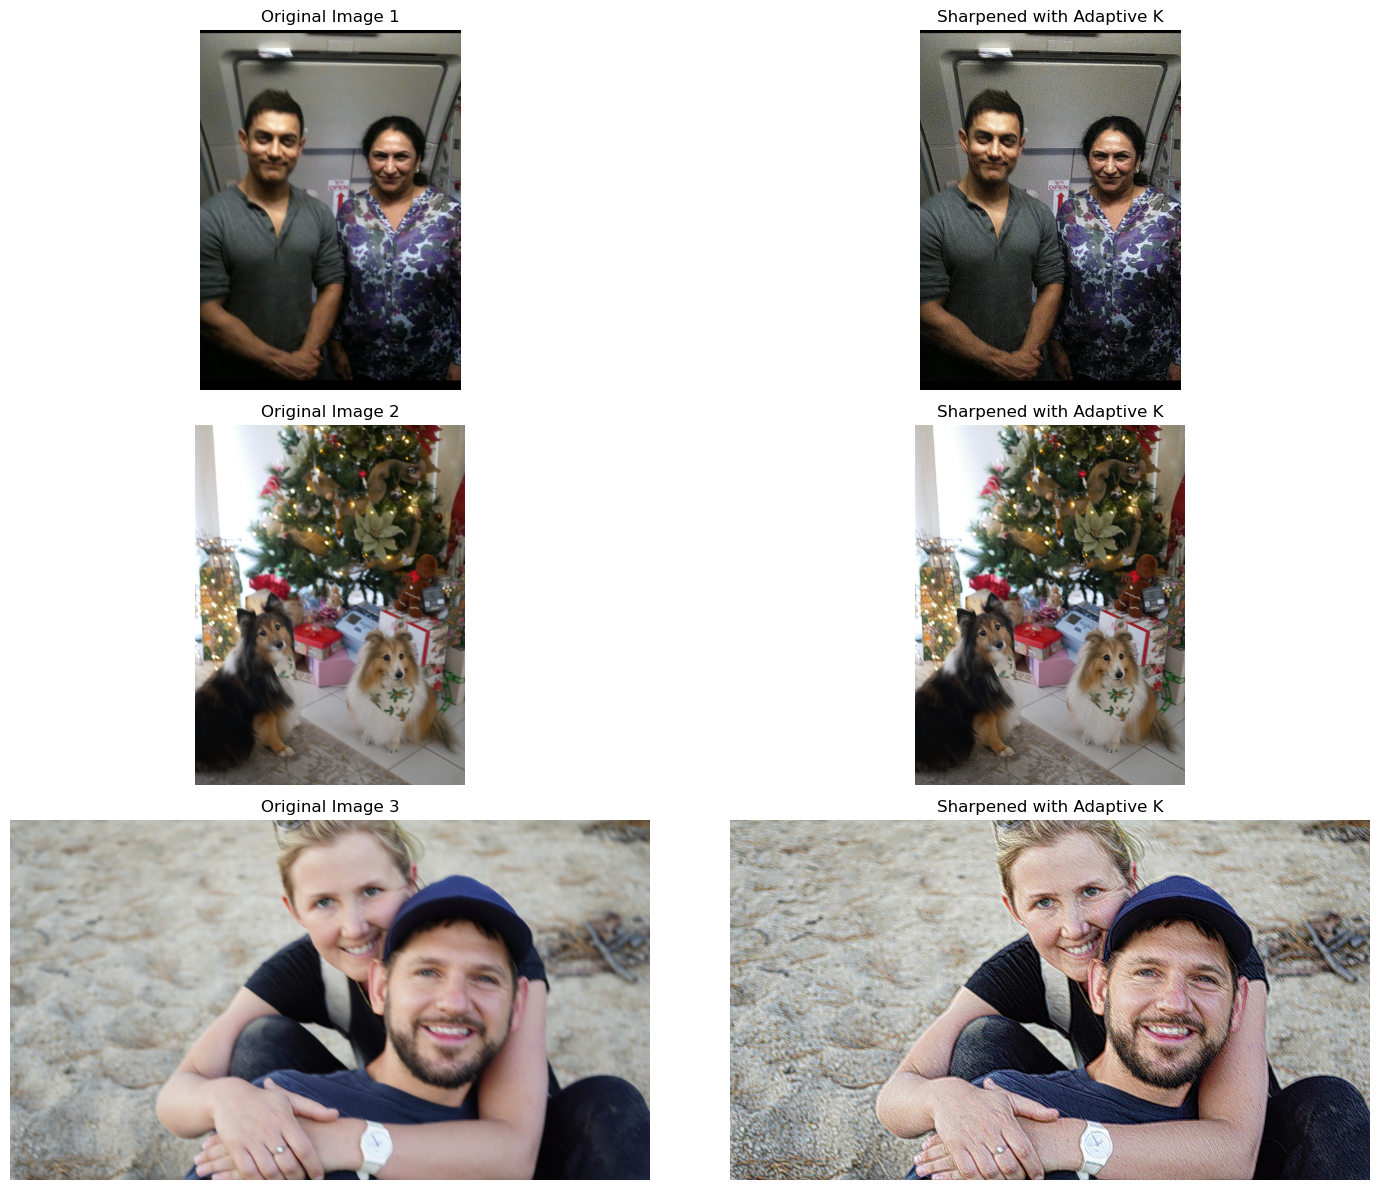

In [7]:
fig, axes = plt.subplots(nrows = 3, ncols = 2, figsize = (15, 12))
K_MAX = 7

for i, img in enumerate(images):
    axes[i, 0].imshow(images[i], cmap='gray')
    axes[i, 0].set_title(f'Original Image {i + 1}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(highBoost_variable(images[i], kernel, K_MAX))
    axes[i, 1].set_title(f'Sharpened with Adaptive K')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()